# Text Classification and Quantitative Evaluation
#### Adapted from a template by Jeremy Merrill for Lede 2026


This notebook classifies text using the OpenAI interface. Right now, it's set up to classify NYT best selling books as romance or non-romance books. 

It includes a cost estimation and code for quantitative evaluation (seeing how you did, then adjusting to try to do better).

It can serve as a template for any kind of classification, and you should feel free to copy and reuse it.

In [ ]:
%pip install -r requirements.txt

In [1]:
import os
import pandas as pd
from IPython.display import display, Markdown
from tqdm.auto import tqdm # makes pretty progress bars
tqdm.pandas()              # makes pretty progress bars in pandas with progress_apply()

# this should be familiar!
from dotenv import load_dotenv
load_dotenv()

/Users/luciacmmackenzie/.venvs/lede/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

## Importing the data 

In [2]:
## importing data
data_dir = ""
data_full = pd.read_csv('data_for_ai_classification.csv')

In [ ]:
data_full.tail()

In [ ]:
data_full.info()

## Cleaning the data and getting a subsample

In [3]:
SIZE_OF_SAMPLE_FOR_HANDCODING = 100
## take a random sample to test our prompts against
text_column_name = "description" # change this to match your own dataset
# drop any nas in the column I am analysing
data_full.dropna(subset=[text_column_name], inplace=True)

# creating an index column. I don't think I need this..
# data_full.set_index("Unnamed: 0", inplace=True)

# # Making date the right data type in case useful down the line
# data_full["published_date_as_date"] = pd.to_datetime(data_full["published_date"])
# data_full["bestsellers_date_as_date"] = pd.to_datetime(data_full["bestsellers_date"])

# for ease of handcoding I am moving the description column to the end
data_full = data_full[[col for col in data_full.columns if col != "description"] + ["description"]]

In [4]:
data_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 2242 entries, 0 to 2241
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0.1              2242 non-null   int64  
 1   Unnamed: 0                2242 non-null   int64  
 2   age_group                 0 non-null      float64
 3   amazon_product_url        2242 non-null   str    
 4   article_chapter_link      0 non-null      float64
 5   asterisk                  2242 non-null   int64  
 6   author                    2242 non-null   str    
 7   book_image                2242 non-null   str    
 8   book_image_height         2242 non-null   int64  
 9   book_image_width          2242 non-null   int64  
 10  book_review_link          117 non-null    str    
 11  book_uri                  2242 non-null   str    
 12  contributor               2242 non-null   str    
 13  contributor_note          6 non-null      str    
 14  created_date       

In [5]:
# if you already did the handcoding, make sure the sample you're using is the right set.
WE_ALREADY_HANDCODED = os.path.exists("handcoded.csv")
if WE_ALREADY_HANDCODED:
  handcoded = pd.read_csv("handcoded.csv")
  data_sample = data_full[data_full.index.isin(handcoded.url)]

# This creates a random sample of 100 descriptions for us to handcode if we haven't already
# 613 is just a random number, you just set a random seed. But if you have the random state the same then you and your neighbour get the same
else:
  data_sample = data_full.sample(n=SIZE_OF_SAMPLE_FOR_HANDCODING, random_state=613)

data_sample = data_sample.copy() # avoid annoying warnings!

In [6]:
data_sample.head()

,Unnamed: 0.1,Unnamed: 0,age_group,amazon_product_url,article_chapter_link,asterisk,author,book_image,book_image_height,book_image_width,...,title,updated_date,weeks_on_list,isbns,buy_links,published_date,bestsellers_date,published_date_as_date,bestsellers_date_as_date,description
1754,6920,5,NaN,https://www.amazon.com/You-Say-First-Small-Tow...,NaN,0,Susan Mallery,https://static01.nyt.com/bestsellers/images/97...,495,313,...,YOU SAY IT FIRST,2026-03-06T15:40:33.798Z,1,"[{'isbn10': '', 'isbn13': '9781488028441'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",2017-09-10,2017-08-26,2017-09-10,2017-08-26,A sculptor takes a job as a carpenter at a the...
2153,8225,10,NaN,http://www.amazon.com/Nobody-But-You-Cedar-Rid...,NaN,0,Jill Shalvis,https://static01.nyt.com/bestsellers/images/97...,495,307,...,NOBODY BUT YOU,2026-03-18T00:07:35.344Z,1,"[{'isbn10': '', 'isbn13': '9781455586790'}]","[{'name': 'Amazon', 'url': 'http://www.amazon....",2016-04-17,2016-04-02,2016-04-17,2016-04-02,"After a disastrous mission, a soldier heads to..."
633,2554,4,NaN,https://www.amazon.com/dp/031645737X?tag=thene...,NaN,0,James Patterson and Brendan DuBois,https://static01.nyt.com/bestsellers/images/97...,500,331,...,COUNTDOWN,2026-03-06T03:53:22.585Z,1,"[{'isbn10': '', 'isbn13': '9780316457378'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",2023-04-09,2023-03-25,2023-04-09,2023-03-25,A botched field operation and a terrorist plot...
626,2511,6,NaN,https://www.amazon.com/dp/1982180021?tag=thene...,NaN,0,J.R. Ward,https://static01.nyt.com/bestsellers/images/97...,500,323,...,LASSITER,2026-03-06T03:57:36.886Z,1,"[{'isbn10': '', 'isbn13': '9781982180065'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",2023-04-30,2023-04-15,2023-04-30,2023-04-15,The 21st book in the Black Dagger Brotherhood ...
1224,5129,14,NaN,https://www.amazon.com/Rise-Magicks-Chronicles...,NaN,0,Nora Roberts,https://static01.nyt.com/bestsellers/images/97...,495,326,...,THE RISE OF MAGICKS,2026-03-06T11:39:40.828Z,3,"[{'isbn10': '', 'isbn13': '9781250123039'}]","[{'name': 'Amazon', 'url': 'https://www.amazon...",2019-12-29,2019-12-14,2019-12-29,2019-12-14,The third book in the Chronicles of the One se...


In [7]:
data_sample.shape

(100, 34)

## Connecting to an AI provider

In [8]:
## setting up our connection to an API client for an AI provider
# for Lede, we're using OpenRouter, which connects to most providers
# but I've provided code for connect to other providers directly, if you want to do that in real life

USE_OPENROUTER=True

from anthropic import Anthropic

if USE_OPENROUTER:
  from openrouter import OpenRouter
else:
  from openai import OpenAI
  from mistralai.client import Mistral

if USE_OPENROUTER:
  openrouter_client = OpenRouter(api_key=os.environ.get("OPENROUTER_API_KEY_LEDE"))
else:
  openai_client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY_LEDE"))
  mistral_client = Mistral(api_key=os.environ.get("MISTRAL_API_KEY_LEDE"))
anthropic_client = Anthropic(api_key=os.environ.get("ANTHROPIC_API_KEY_LEDE"),) # intentionally created outside of the if; we'll use anthropic_client to count tokens (even if we're using openrouter)


## Writing the prompt

A basic format for a prompt is below. Using the web version of ChatGPT (chatgpt.com) tweak this until you're pretty consistently getting reasonable results.

In [9]:
## prompt
# Be sure to list the categories (defined below!) with the magic phrase {categories}
prompt_base = """

This is a short description of a book that has been on the New York Times best seller list in the past decade. I need you to tell me if it is a romance book.

Which one of these categories is it: {categories}.

Here is the description: {description}


"""

from enum import Enum, IntEnum

# force the AI to ONLY guess fromn the options we ask you.
# you can change these names! (and perhaps should!)
# - the AI sees the _value_, not the key (it sees "broader_political_issues_except_us_election", not "other_politics")
# - the key is just for you -- a shorthand
# - some AIs have trouble with complicated names, so it's better to stick to lowercase, no special characters
#     (as of early June 2026 -- maybe this will be fixed)
class DescriptionProtagonistOptions(str, Enum):
    romance = "genre_is_romance"
    other = "genre_is_not_romance"


# for convenience, make a column in our dataframes with the prompt for each item
data_sample_prompt_column = data_sample.apply(lambda row: prompt_base.format(
    description=row[text_column_name],
    categories=", ".join(['"{}"'.format(opt.value) for opt in DescriptionProtagonistOptions])
), axis="columns")
full_data_prompt_column = data_full.apply(lambda row: prompt_base.format(
    description=row[text_column_name],
    categories=", ".join(['"{}"'.format(opt.value) for opt in DescriptionProtagonistOptions])
), axis="columns")

In [10]:
# This checks that this is working
print(data_sample_prompt_column.iloc[0])



This is a short description of a book that has been on the New York Times best seller list in the past decade. I need you to tell me if it is a romance book.

Which one of these categories is it: "genre_is_romance", "genre_is_not_romance".

Here is the description: A sculptor takes a job as a carpenter at a theme wedding venue and falls for its owner, Pallas Saunders, who is trying to save the business. The first book in the Happily Inc. series.





## Cost estimation

In [11]:
## cost estimation

from strip_tags import strip_tags
import tiktoken
def count_tokens(model, text):
  if "claude" in model and os.environ.get("ANTHROPIC_API_KEY_LEDE"):
    return anthropic_client.messages.count_tokens(model=model, messages=[{"content": text, "role": "user"}])
  elif "gpt" in model:
    encoding = tiktoken.encoding_for_model('gpt-4o') # most modern models use the same tokenizer
    tokens = encoding.encode(text)
    return len(tokens)
  else:
    return count_tokens("gpt-4o", text) # for estimation purposes, pretend mistral is chatgpt...

INPUT_TOKEN_COSTS = {
    "gpt-5-mini": 0.40 / 1_000_000,  # https://openai.com/api/pricing/
    "gpt-5.4-mini": 0.75 / 1_000_000,
    "gpt-5.4": 2.5 / 1_000_000,
    "gpt-5.5": 5 / 1_000_000,
    "gpt-5.4-nano": 0.2 / 1_000_000,
    "mistral-medium-latest": 1.5 / 1_000_000, # https://mistral.ai/pricing#api-pricing
    "mistral-large-latest":  0.5 / 1_000_000,  # No, I don't know why medium is more expensive than large.
    "claude-4.5-haiku": 1 / 1_000_000,
    "claude-4.6-sonnet": 3 / 1_000_000
}
# ignores outputs, since the model will output fairly little text

def estimate_cost(model, token_count):
    return token_count * INPUT_TOKEN_COSTS[model]


In [12]:
# IMPORTANT: let's pick a model to use
# it's got to be listed in INPUT_TOKEN_COSTS up above

DEFAULT_MODEL_TO_USE = 'gpt-5.4-nano'
display(Markdown("Pick a model to use: \n" + "\n - ".join(list(INPUT_TOKEN_COSTS.keys()))))
MODEL_TO_USE = None

while MODEL_TO_USE not in INPUT_TOKEN_COSTS.keys():
  MODEL_TO_USE = input(f"type a model name (press enter for default: {DEFAULT_MODEL_TO_USE}): ").strip()
  if MODEL_TO_USE == "":
    MODEL_TO_USE = DEFAULT_MODEL_TO_USE


Pick a model to use: 
gpt-5-mini
 - gpt-5.4-mini
 - gpt-5.4
 - gpt-5.5
 - gpt-5.4-nano
 - mistral-medium-latest
 - mistral-large-latest
 - claude-4.5-haiku
 - claude-4.6-sonnet

type a model name (press enter for default: gpt-5.4-nano):  gpt-5.4-mini


In [13]:
## cost estimation sample

count_tokens_for_our_model = lambda text: count_tokens(MODEL_TO_USE, text)

token_count_sample = count_tokens_for_our_model("SAMPLE RESPONSE SAMPLE RESPONSE".join(data_sample_prompt_column))
"Sample would cost: ${:.2f}".format(estimate_cost(MODEL_TO_USE, token_count_sample))

'Sample would cost: $0.01'

In [14]:
## cost estimation for full dataset
token_count_full = count_tokens_for_our_model("SAMPLE RESPONSE SAMPLE RESPONSE".join(full_data_prompt_column))
"Full dataset would cost: ${:.2f}".format(estimate_cost(MODEL_TO_USE, token_count_full))

'Full dataset would cost: $0.16'

## Sending the query to the AI 

In [15]:

## a lot of boilerplate for sending our prompt + tweet to the model and getting an answer
from pydantic import BaseModel

# I needed to replace
# MuskTweetValidOptions with DescriptionProtagonistValidOptions
# and MuskTweetOptions with DescriptionProtagonistOptions

class DescriptionProtagonistValidOptions(BaseModel):
  classification: DescriptionProtagonistOptions

SYSTEM_PROMPT = "You are a helpful assistant"

def anthropic_classify(prompt_including_tweet):
    # put our prompt into the blob that OpenAI expects
    message = anthropic_client.messages.parse(
        max_tokens=1024,
        # system=SYSTEM_PROMPT, # causes trouble with structured outputs, oddly
        messages = [
            {
                "role": "user",
                "content": prompt_including_tweet,
            }
        ],
        model=MODEL_TO_USE,
        output_format=DescriptionProtagonistValidOptions
    )
    return message.content[0].parsed_output.classification.value if message.content[0].parsed_output else None

def mistral_classify(prompt_including_tweet):
    # put our prompt into the blob that OpenAI expects
    chat_response = mistral_client.chat.parse(
      model=MODEL_TO_USE,
      messages=[
          {
              "role": "system",
              "content": SYSTEM_PROMPT
          },
          {
              "role": "user",
              "content": prompt_including_tweet
          },
      ],
      response_format=DescriptionProtagonistValidOptions,
      max_tokens=256,
      temperature=0
    )
    return chat_response.choices[0].message.parsed.classification.value if chat_response.choices[0].message.parsed else None

def chatgpt_classify(prompt_including_tweet):
    # put our prompt into the blob that OpenAI expects
    messages = [
        {
            "role": "system",
            "content": SYSTEM_PROMPT
        },
        {
            "role": "user",
            "content": prompt_including_tweet,
        }
    ]
    chat_completion = openai_client.responses.parse(
        input=messages,
        model=MODEL_TO_USE,
        text_format=DescriptionProtagonistValidOptions,
    )

    # get the answer out of the blob that OpenAI returns.
    resp = chat_completion.output_parsed.classification.value if chat_completion.output_parsed else None
    return resp

openrouter_model_names = {
    "gpt-5-mini": "openai/gpt-5-mini",
    "gpt-5.4-mini": "openai/gpt-5.4-mini",
    "gpt-5.4": "openai/gpt-5.4",
    "gpt-5.5": "openai/gpt-5.5",
    "gpt-5.4-nano": "openai/gpt-5.4-nano",
    "mistral-medium-latest": "mistralai/mistral-medium-3-5",
    "mistral-large-latest": "mistralai/mistral-large-2512",
    "claude-4.5-haiku": "anthropic/claude-4.5-haiku",
    "claude-4.6-sonnet": "anthropic/claude-4.6-sonnet"
}
def openrouter_classify(prompt_including_tweet):
    response = openrouter_client.chat.send(
        model=openrouter_model_names[MODEL_TO_USE],
        messages=[
            {"role": "user", "content": prompt_including_tweet}
        ],
        response_format={
            "type": "json_schema",
            "json_schema": {
                "name": "description_protagonist_classification",
                "strict": True,
                "schema": DescriptionProtagonistValidOptions.model_json_schema(),
            },
        },
    )
    return  DescriptionProtagonistValidOptions.model_validate_json(
        response.choices[0].message.content
    ).classification.value

def classify(prompt_including_tweet):
  "A wrapper for the provider-specific classification functions"
  if USE_OPENROUTER:
    return openrouter_classify(prompt_including_tweet)
  else:
    if "mistral" in MODEL_TO_USE == "mistral-medium-latest":
      return mistral_classify(prompt_including_tweet)
    elif "claude" in MODEL_TO_USE:
      return anthropic_classify(prompt_including_tweet)
    elif "gpt" in MODEL_TO_USE:
      return chatgpt_classify(prompt_including_tweet)
    else:
      raise ValueError("Unknown model")

In [16]:
# ask ChatGPT about each and every tweet IN THE SAMPLE, using the prompt we made above
data_sample["ai_guess"] = data_sample_prompt_column.progress_apply(classify)

100%|████████████████████████████████████████| 100/100 [02:18<00:00,  1.39s/it]


In [17]:
display(Markdown("## Here are a few results. How good did we do?"))
with pd.option_context("display.max_colwidth", 500):
  display(
      data_sample[[text_column_name, "ai_guess"]].head(5)
  )

## Here are a few results. How good did we do?

,description,ai_guess
1754,"A sculptor takes a job as a carpenter at a theme wedding venue and falls for its owner, Pallas Saunders, who is trying to save the business. The first book in the Happily Inc. series.",genre_is_romance
2153,"After a disastrous mission, a soldier heads to a lakeside cabin where a wayward woman has docked her boat.",genre_is_not_romance
633,A botched field operation and a terrorist plot endanger Amy Cornwall and her family.,genre_is_not_romance
626,The 21st book in the Black Dagger Brotherhood series. A fallen angel meets a mysterious female.,genre_is_not_romance
1224,The third book in the Chronicles of the One series. Fallon Swift goes up against an old foe.,genre_is_not_romance


Not well at all, I would say one of those is a romance novel 

## Handcoding to check the model's accuracy


In [18]:
# This code will adds a new blank 'groundtruth' column, then exports it to CSV, and downloads it.
data_sample.to_csv('data_for_analysis/book_descriptions_for_hand_classification.csv')

Now open that CSV in Google Sheets or Excel, and fill in the groundtruth column with the right answer.

Then upload it back here (by clicking the folder icon to the left), or, if you're using a Jupyter Notebook, put it in the same folder as your notebook. Important name the file handcoded.csv.

In [19]:
# this is where the index thing came in 
handcoded = pd.read_csv("handcoded.csv") # for some countries add `, delimiter=";"`
if "groundtruth" not in handcoded.columns:
  print("uh oh, your handcoded.csv doesn't have a column named groundtruth")
  assert "groundtruth" in handcoded.columns
if handcoded.groundtruth.isna().any() or (handcoded.groundtruth == '').any():
  print("uh oh, there are some blanks in your handcoded.csv's groundtruth column. go fix that!")

# if the ai_guess column got lost in the process... we'll grab it again
if "ai_guess" not in handcoded:
  handcoded = handcoded.merge(data_sample[["ai_guess"]], right_index=True, left_index=True)

In [20]:
from sklearn.metrics import accuracy_score
display(Markdown("Accuracy score: {:.1%}. Is that good?".format(
    accuracy_score(handcoded["groundtruth"], handcoded["ai_guess"])
)))


Accuracy score: 95.0%. Is that good?


  This is a confusion matrix, that displays the count of each combo of possible answers and predictions.

  What conclusion do we draw from this?

  What kinds of errors are most common?
  

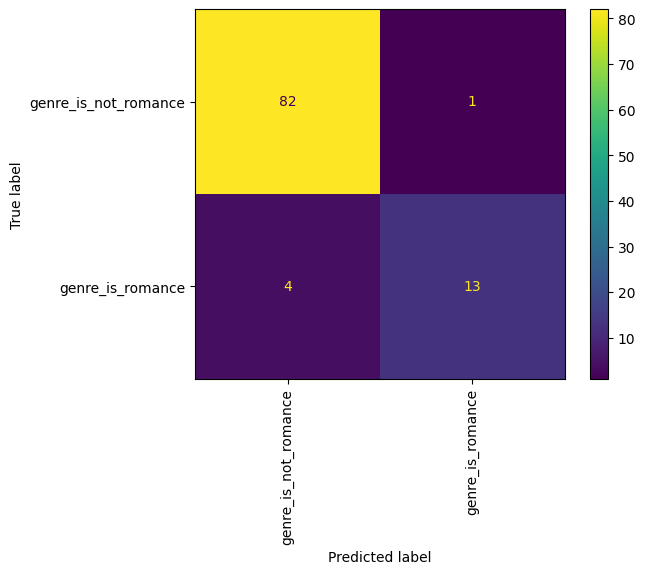

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(handcoded["groundtruth"], handcoded["ai_guess"],  xticks_rotation="vertical");
display(Markdown("""
  This is a confusion matrix, that displays the count of each combo of possible answers and predictions.

  What conclusion do we draw from this?

  What kinds of errors are most common?
  """))

What I can see here is that my model is reasonably accurate, but is struggling to identify all the romances

In [22]:
# calculate baseline
accuracy = accuracy_score(handcoded["groundtruth"], handcoded["ai_guess"])
most_common_answer = handcoded.groupby("groundtruth").count().idxmax().ai_guess
baseline = accuracy_score(handcoded["groundtruth"], [most_common_answer] * len(handcoded["ai_guess"]))


display(Markdown("""is {:.1%} good? Well, let's measure *model skill*. Is the AI _doing anything_?

Let's compare it to the stupidest model possible, that just guesses the most common class ({}) for all outputs. That **baseline** is {:.1%}.

How does {:.1%} compare to {:.1%}?
""".format(
    accuracy,
    most_common_answer,
    baseline,
    accuracy,
    baseline
)))

is 95.0% good? Well, let's measure *model skill*. Is the AI _doing anything_?

Let's compare it to the stupidest model possible, that just guesses the most common class (genre_is_not_romance) for all outputs. That **baseline** is 83.0%.

How does 95.0% compare to 83.0%?


In [23]:
if accuracy <= baseline:
  new_baseline = accuracy_score(handcoded["groundtruth"], [most_common_answer] * len(handcoded["2-way_category_ai"]))

  display(Markdown("""
    The model is doing worse than (or maybe even with) the baseline.

    But that comparison treats false-positives and false-negatives as equally bad. That might not be right for your problem. For the insults problem,
    all we want to do is shrink the haystack. A baseline that guesses nothing is an insult (as our baseline does) is useless to us. The real
    baseline (reading all of Trump's tweets to find place insults) would be guessing the insult class for everything. That baseline gets {:.1%} --
    way worse than {}. Phew.

    This makes intuitive sense. An AI classification that shrinks the haystack, with a mixture of false-positives and true-positives for us to look at
    is actually really helpful.
  """.format(
      new_baseline,
      accuracy
  )))
else:
  display(Markdown("""
    The model is doing better than baseline.

But maybe we can do even better. Look at the model's mistakes below, adjust the prompt, and see if the accuracy score (or your chosen metric) goes up.
  """.strip()))

with pd.option_context("display.max_colwidth", 500):
  display(
      handcoded[handcoded["ai_guess"] != handcoded["groundtruth"]][[text_column_name, "groundtruth", "ai_guess"]]
  )

The model is doing better than baseline.

But maybe we can do even better. Look at the model's mistakes below, adjust the prompt, and see if the accuracy score (or your chosen metric) goes up.

,description,groundtruth,ai_guess
1,"After a disastrous mission, a soldier heads to a lakeside cabin where a wayward woman has docked her boat.",genre_is_romance,genre_is_not_romance
3,The 21st book in the Black Dagger Brotherhood series. A fallen angel meets a mysterious female.,genre_is_romance,genre_is_not_romance
24,A woman who has rented out her South Carolina beach house for the summer winds up sharing it with her tenant when she is faced with a tragedy.,genre_is_not_romance,genre_is_romance
40,Sophie Drear is hired to revitalize a manor in coastal Maine and discovers a secret garden where a mysterious figure dwells.,genre_is_romance,genre_is_not_romance
64,"The marriage of a cunning London tycoon to a shy, beautiful woman invites a conspiracy against them and the revelation of a dark secret.",genre_is_romance,genre_is_not_romance


I think AI should be able to get some of these. It is struggling with mysterious relationships.

## Redoing the prompt to improve accuracy

In [33]:
text_column_name2 = "title"
new_prompt_base = """

This is a short description and the title of a book that has been on the New York Times best seller list in the past decade. Use both the descriptiona nd title to tell me if the book's main genre is romance.

Which one of these categories is it: {categories}.

Here is the description: {description}

Here is the title: {title}



"""



data_sample_new_prompt_column = handcoded.apply(lambda row: new_prompt_base.format(
    description=row[text_column_name],
    title = row[text_column_name2],
    categories=", ".join(['"{}"'.format(opt.value) for opt in DescriptionProtagonistOptions])
), axis="columns")
token_count_sample = count_tokens_for_our_model("SAMPLE RESPONSE SAMPLE RESPONSE".join(data_sample_new_prompt_column))
"Sample would cost: ${:.2f}".format(estimate_cost(MODEL_TO_USE, token_count_sample))

'Sample would cost: $0.01'

In [34]:
handcoded["new_ai_guess"] = data_sample_new_prompt_column.progress_apply(classify)

100%|████████████████████████████████████████| 100/100 [02:15<00:00,  1.36s/it]


In [35]:
accuracy = accuracy_score(handcoded["groundtruth"], handcoded["new_ai_guess"])
original_prompt_accuracy = accuracy_score(handcoded["groundtruth"], handcoded["ai_guess"])

In [36]:
display(Markdown("""
  Your new prompt got an accuracy rate of {:.0%}. Is that better than {:.0%}?

  Should we be using a different metric? (You tell me!)

  Keep trying new stuff until it's good enough (whatever that means!) or you get bored.

  Then you can classify the whole dataset.
""".format(accuracy, original_prompt_accuracy)))


  Your new prompt got an accuracy rate of 97%. Is that better than 95%?

  Should we be using a different metric? (You tell me!)

  Keep trying new stuff until it's good enough (whatever that means!) or you get bored.

  Then you can classify the whole dataset.


In [37]:
with pd.option_context("display.max_colwidth", 500):
  display(
      handcoded[handcoded["new_ai_guess"] != handcoded["groundtruth"]][[text_column_name, "groundtruth", "new_ai_guess"]]
  )

,description,groundtruth,new_ai_guess
3,The 21st book in the Black Dagger Brotherhood series. A fallen angel meets a mysterious female.,genre_is_romance,genre_is_not_romance
24,A woman who has rented out her South Carolina beach house for the summer winds up sharing it with her tenant when she is faced with a tragedy.,genre_is_not_romance,genre_is_romance
40,Sophie Drear is hired to revitalize a manor in coastal Maine and discovers a secret garden where a mysterious figure dwells.,genre_is_romance,genre_is_not_romance


This improved things enough to run the whole data set

## Running the model on the full data set

In [39]:
# since running the AI over the whole dataset might cost a real amount of money
# this is just an extra check to make sure you want to do it.
# just hit enter (or type anything) to continue
# hit stop (to the left of this cell) to stop
okay_to_do_the_whole_thing = input()

In [40]:
## creating response generator -- full dataset

# we're using the most recent "new prompt"
# I have changed this to the original base 
data_full_prompt_column = new_prompt_base + data_full[text_column_name] + data_full[text_column_name2]


In [41]:
## classifying full prompt and saving as a csv

data_full["ai_guess"] = data_full_prompt_column.progress_apply(classify)
data_full.to_csv("data_for_analysis/book_genre_ai_classified.csv")

100%|██████████████████████████████████████| 2242/2242 [49:11<00:00,  1.32s/it]
